# Lecture 6 - More Trees! Bagging and Random Forest

## Midterm results posted

![](canvas.png)
![](midterm-summary2.png)
![](question-grades.png)

### Midcourse [survey](https://forms.office.com/r/Bb9UZCc5Sr)!

## Today's Class

By the end of this class, you will be able to

- Understand the issue of decision trees overfitting and why a fully grown tree may perform poorly on new data.
- Describe pre-pruning (stopping rules) vs. post-pruning and explain how each controls tree complexity.
- Use cost-complexity pruning (`ccp_alpha`) to select an optimal tree size using cross-validation.
- Explain the idea behind **bagging** (bootstrap aggregating) and why averaging many trees reduces variance.
- Describe how **random forests** extend bagging by adding random feature selection at each split.
- Fit a random forest using `RandomForestClassifier` and tune key parameters (`n_estimators`, `max_features`).
- Compute and interpret **variable importance** based on mean decrease in **Gini impurity (gain)**.
- Compare single tree, bagged tree, and random forest using test-set metrics.
- Show that we can use tree methods like random forest for both classification (binary or categorical outcomes) and regression (continuous outcomes). In the lecture we will show binary and continuous outcomes, in lab you will try a categorical outcome.

## CPS Employment Data: Recent Graduates

Similar to the data used for decision trees, we use individual-level microdata from the [IPUMS CPS](https://cps.ipums.org/cps/) Annual Social and Economic Supplement (ASEC), 2020–2025.

The dataset has been filtered to **recent graduates**: ages 22–30 with a bachelor's degree or higher. For the first part, we are interested in  what variables (features) predict employment status in recent university graduates. In the second part, we are interested in what variables (features) predict salary in recent university graduates.

### Target variable for classification (binary)

| Variable | Description | Type | Values |
|----------|-------------|------|--------|
| `employed` | Binary employment status | Binary | 0 = Unemployed, 1 = Employed |

### Target variable for regression (continuous)

| Variable | Description | Type | Values |
|----------|-------------|------|--------|
| `INCWAGE` | Wage and salary income | Numeric | Dollar amount |

### Predictor variables

| Variable | Description | Type | Values |
|----------|-------------|------|--------|
| `AGE` | Age in years | Numeric | 22–30 |
| `female` | Sex | Binary | 0 = Male, 1 = Female |
| `married` | Marital status | Binary | 0 = Not married, 1 = Married |
| `educ_cat` | Education level | Ordinal | 4 = Bachelor's, 5 = Graduate |
| `faminc_cat` | Family income bracket | Ordinal | 1 = Low (<$40k), 2 = Middle ($40k–$100k), 3 = High ($100k+) |
| `metro_binary` | Metropolitan area | Binary | 0 = Non-metro, 1 = Metro |
| `race_cat` | Race | Categorical | White, Black, Asian, Other |
| `us_citizen` | US citizenship | Binary | 0 = Not a citizen, 1 = US citizen |
| `has_children` | Has children in household | Binary | 0 = No, 1 = Yes |
| `insured` | Health insurance last year | Binary | 0 = No, 1 = Yes |
| `INCWAGE` | Wage and salary income | Numeric | Dollar amount |
| `FIRMSIZE` | Employer firm size | Ordinal | 0–9 |
| `NCHILD` | Number of own children | Numeric | 0–9 |
| `YEAR` | Survey year | Numeric | 2020–2025 |
| `STATEFIP` | State FIPS code | Numeric | 1–56 |

Let's read in the data and check the shape and summarize the target variable `employed`.
Note for fitting Random Forest models we use `sklearn.ensemble` and select `RandomForestClassifier`

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, roc_auc_score)

# Import and summarize the target variables
cps = pd.read_csv('cps_empl.csv')
print(f"Dataset shape: {cps.shape}")
print()
print("Target distribution (employed):")
print(cps['employed'].value_counts().sort_index())
print()
print(cps['INCWAGE'].describe())
print()
cps.head()

Dataset shape: (21626, 19)

Target distribution (employed):
employed
0      850
1    20776
Name: count, dtype: int64

count    2.162600e+04
mean     5.814871e+04
std      5.967450e+04
min      0.000000e+00
25%      2.700000e+04
50%      5.000000e+04
75%      7.500000e+04
max      1.105000e+06
Name: INCWAGE, dtype: float64



,AGE,female,married,educ_cat,faminc_cat,metro_binary,race_cat,us_citizen,has_children,insured,OCC,IND,INCWAGE,FIRMSIZE,NCHILD,YEAR,STATEFIP,worker_cat,employed
0,23,0,0,4,2,0,White,1,0,1,2205,7870,55000,9,0,2020,23,Part-time,1
1,30,1,0,4,1,0,White,1,0,1,3602,8290,47200,5,0,2020,23,Private for-profit,1
2,23,0,0,4,3,0,Asian,1,0,1,9130,8680,2000,1,0,2020,23,Part-time,1
3,30,0,1,4,2,0,Other,1,1,1,3870,9590,85000,9,1,2020,23,Government,1
4,29,1,1,4,2,0,White,1,1,1,2360,7890,20000,1,1,2020,23,Part-time,1


Because the variable race is of character type (Asian, Black, White, ...) we recode to have binary variables for race (scikit-learn's tree models require numeric inputs, however string/characters for targets y are ok.) Note we keep one "reference group" like we would in linear or logistic regression.

Let's recode and then split the data 80%-20% training-test sets

In [147]:
# Encode race_cat as binary variables using panda's get_dummies
cps_encoded = pd.get_dummies(cps, columns=['race_cat'], drop_first=True)

# Features/predictor variables
# Exclude targets (employed, worker_cat), raw codes (OCC, IND, STATEFIP),
# and INCWAGE/FIRMSIZE — both are near-zero for unemployed workers (data leakage)
feature_cols = ['AGE', 'female', 'married', 'educ_cat', 'faminc_cat',
                'metro_binary', 'us_citizen', 'has_children', 'insured',
                'NCHILD', 'YEAR',
                'race_cat_Black', 'race_cat_Other', 'race_cat_White']

X = cps_encoded[feature_cols]
y_binary = cps_encoded['employed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=272, stratify=y_binary)

print(f'Training set: {len(X_train):,}')
print(f'Test set:     {len(X_test):,}')
print(f'Baseline (majority class): {y_train.mean():.3f}')

Training set: 17,300
Test set:     4,326
Baseline (majority class): 0.961


Notice that we have a very large class imbalance with only 4% unemployed.

## Review: Decision Tree for Employment

Before diving into overfitting and ensemble methods, let's fit a simple decision tree to predict binary employment status (`employed`) using the CPS data. We only set the `max_depth` to 3. Recall `criterion='gini'` tells the tree how to choose splits. It picks the split that reduces Gini impurity the most (makes the child nodes more “pure”).

In [149]:
# Fit a decision tree with max_depth=3
dt_review = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=272)
dt_review.fit(X_train, y_train)

print(f"Tree depth: {dt_review.get_depth()}")
print(f"Tree leaves: {dt_review.get_n_leaves()}")
print(f"Training accuracy: {accuracy_score(y_train, dt_review.predict(X_train)):.3f}")
print(f"Test accuracy:     {accuracy_score(y_test, dt_review.predict(X_test)):.3f}")

Tree depth: 3
Tree leaves: 8
Training accuracy: 0.961
Test accuracy:     0.961


With a depth of 3, we end up with 8 leaves and a very good test accuracy.
Let's plot the tree

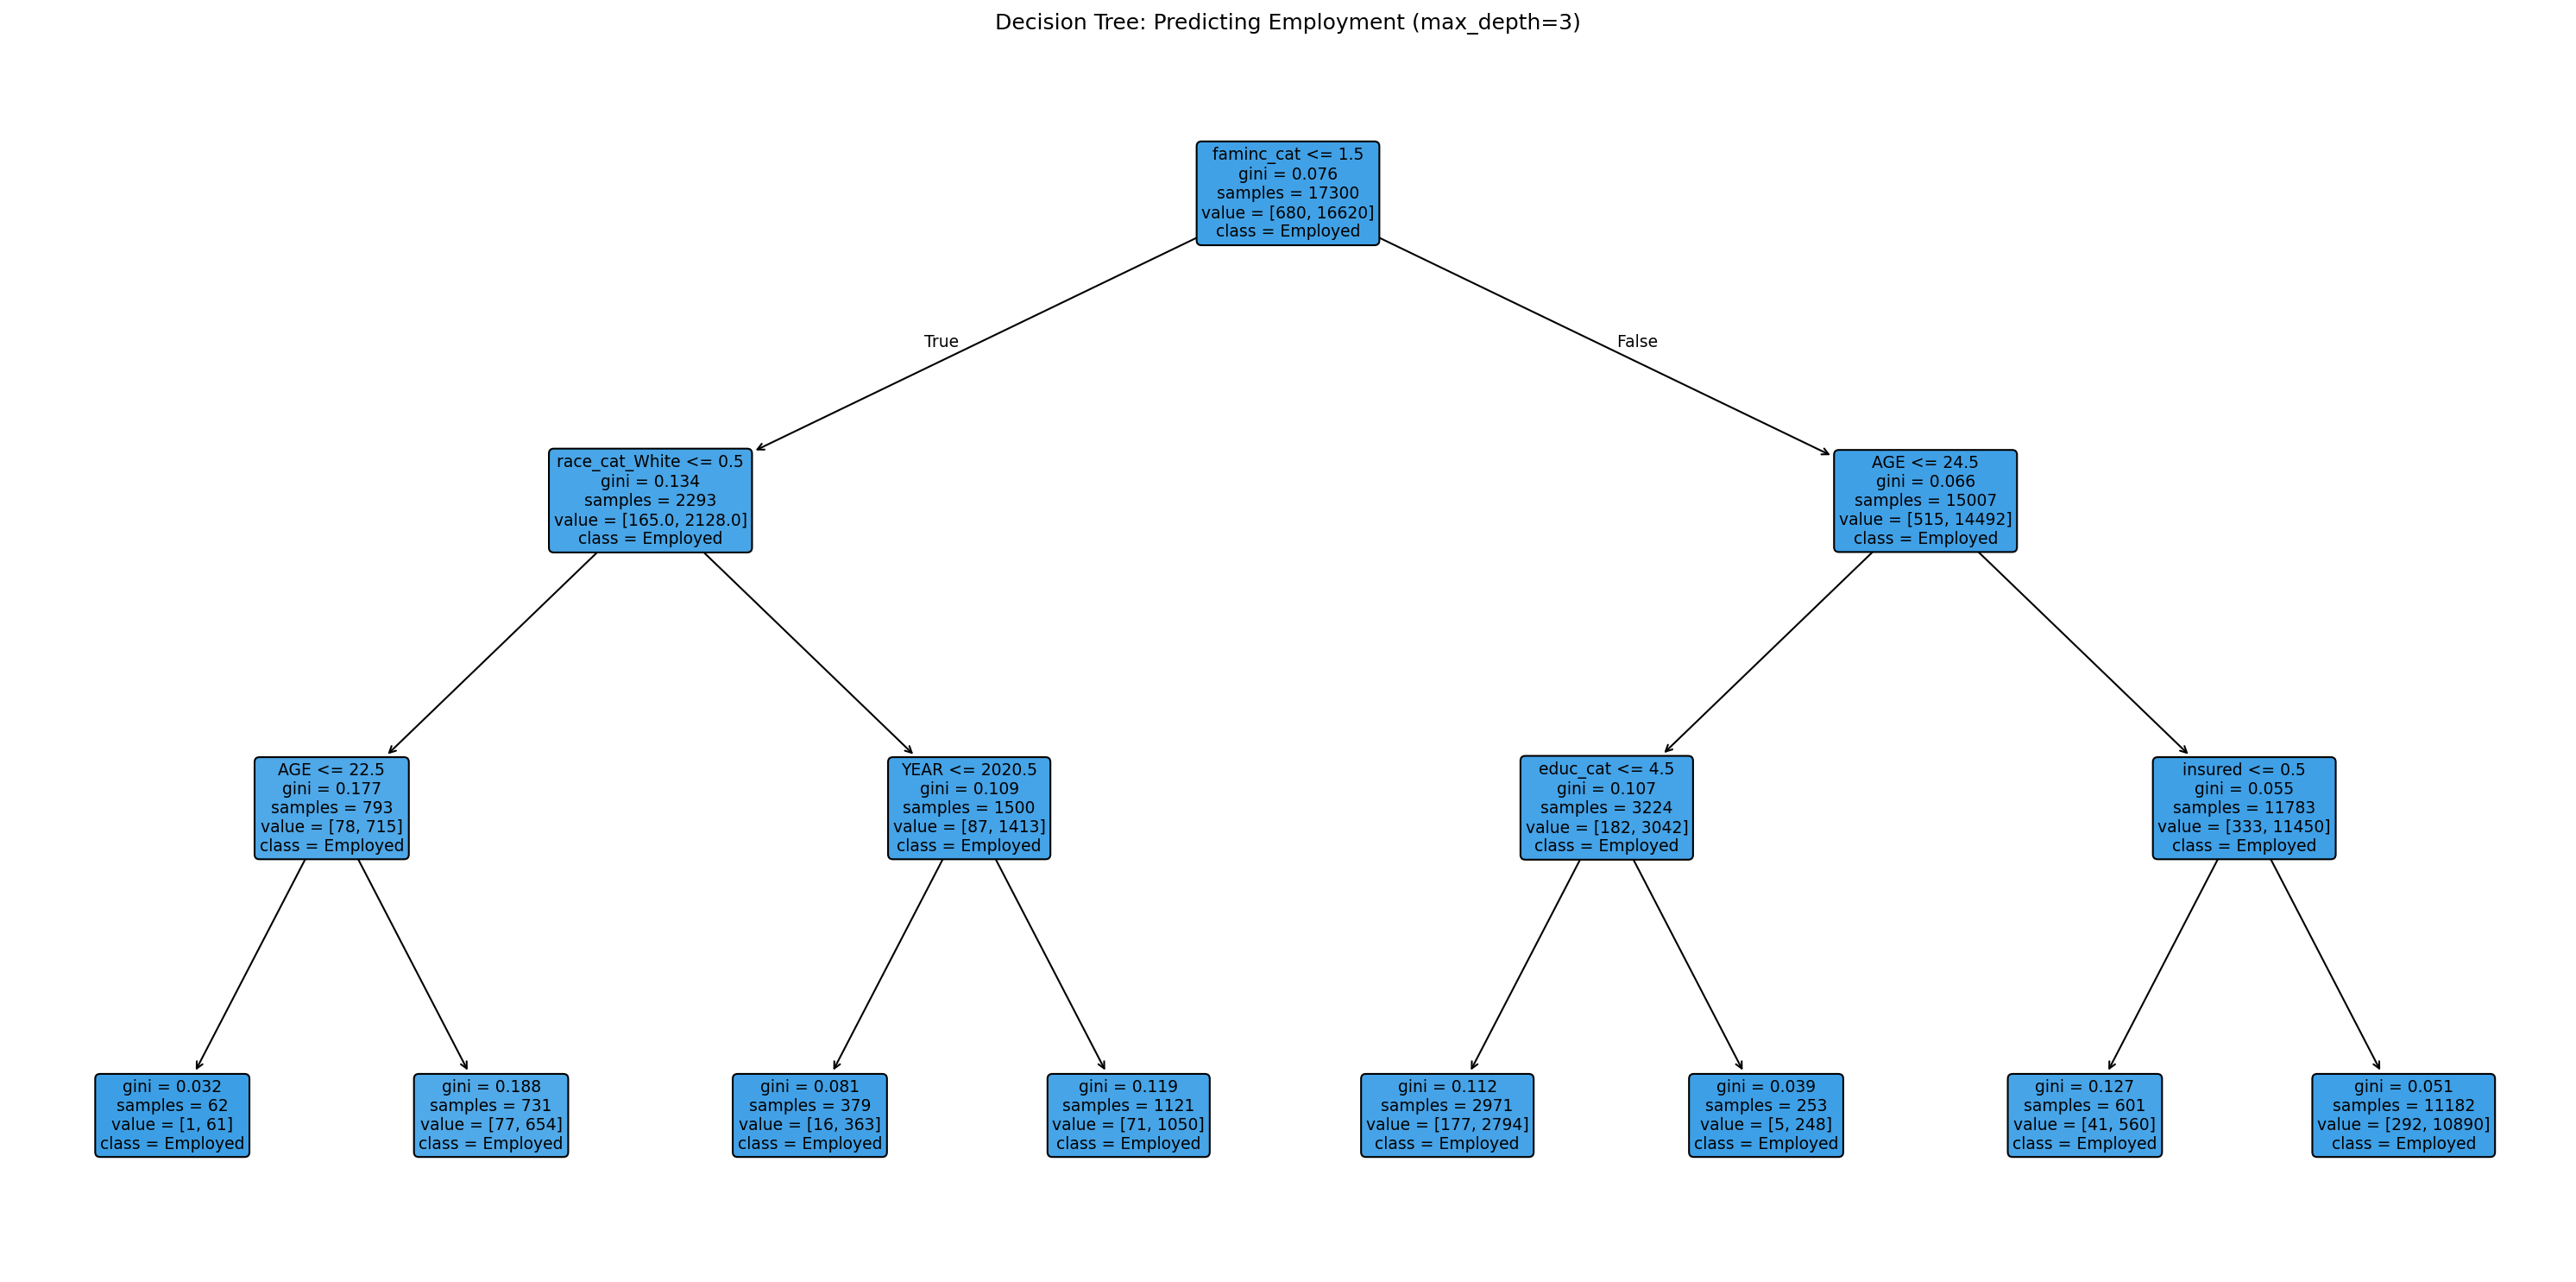

In [150]:
# Visualize the decision tree
plt.figure(figsize=(20, 10), dpi=150)
plot_tree(dt_review,
          feature_names=feature_cols,
          class_names=['Unemployed', 'Employed'],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title('Decision Tree: Predicting Employment (max_depth=3)')
plt.tight_layout()
plt.show()

In [151]:
# Classification report
print("Decision Tree Classification Report:")
print()
print(classification_report(y_test, dt_review.predict(X_test),
                            target_names=['Unemployed', 'Employed'], digits=3))

Decision Tree Classification Report:

              precision    recall  f1-score   support

  Unemployed      0.000     0.000     0.000       170
    Employed      0.961     1.000     0.980      4156

    accuracy                          0.961      4326
   macro avg      0.480     0.500     0.490      4326
weighted avg      0.923     0.961     0.941      4326



**Summary of the Classification Report**: The decision tree achieves 96.1\% accuracy, but this is driven entirely by predicting the majority class (Employed) almost perfectly (recall 1.00, F1 0.98 for that class). It completely fails to identify Unemployed cases (precision/recall/F1 all 0.00), which is reflected in the low macro-average F1 of 0.49 despite strong weighted metrics.

In [152]:
# Confusion matrix for the decision tree
cm = confusion_matrix(y_test, dt_review.predict(X_test))
cm_df = pd.DataFrame(cm, index=['Actual: Unemployed', 'Actual: Employed'],
                     columns=['Predicted: Unemployed', 'Predicted: Employed'])
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
                    Predicted: Unemployed  Predicted: Employed
Actual: Unemployed                      0                  170
Actual: Employed                        0                 4156


### What happened?

The decision tree predicts **everyone** as Employed! The accuracy is 96.1%, but that's exactly the proportion of employed graduates in the data.

Is this because `max_depth=3` is too shallow? Not entirely — even a fully grown tree (depth 28, which we'll fit shortly) gets only 92.6% test accuracy, which is actually **worse** than always predicting the majority class.

The core issue is **class imbalance**:

- Only ~4% of the recent graduates in this data are unemployed.
- A model that always predicts "Employed" gets 96% accuracy for free — without learning anything useful.
- The precision and recall for the Unemployed class are both **0.000** — the tree never predicts anyone as unemployed.

**Lesson:** Accuracy alone can be misleading with imbalanced data. Always check the **confusion matrix** and **per-class metrics** (precision, recall, F1).

We'll see later whether ensemble methods (bagging, random forests) can do better at detecting the minority class.

**Partial fix**: use `class_weight = balanced` in `DecisionTreeClassifier`. This tells the tree to upweight the minority class and downweight the majority class when it decides how to split. For class k,
$$w_k = \frac{n}{K\,n_k}$$
where $n$ = total number of training samples, $K$ = number of classes, $n_k$ = number of samples in class $k$

So each class gets total weight about $n/K$, making the classes “count” equally overall.


## The Overfitting Problem

A **fully grown tree** (no stopping rules) memorizes the training data — it creates a leaf for nearly every unique combination of feature values.

- Training accuracy can be near 100%.
- Test accuracy is often much worse because the tree has learned **noise**, not **signal**.

Let's see this in action with the CPS employment data.

In [153]:
# A fully grown tree (no restrictions)
dt_full = DecisionTreeClassifier(criterion='gini', class_weight='balanced', random_state=272)
dt_full.fit(X_train, y_train)

print(f"Full tree depth: {dt_full.get_depth()}")
print(f"Full tree leaves: {dt_full.get_n_leaves()}")
print(f"Training accuracy: {accuracy_score(y_train, dt_full.predict(X_train)):.3f}")
print(f"Test accuracy:     {accuracy_score(y_test, dt_full.predict(X_test)):.3f}")

Full tree depth: 21
Full tree leaves: 1654
Training accuracy: 0.832
Test accuracy:     0.783


In [154]:
# Compare with a restricted tree
dt_restricted = DecisionTreeClassifier(criterion='gini', max_depth=15,
                                       min_samples_split=10, min_samples_leaf=10,
                                       class_weight='balanced',
                                       random_state=272)
dt_restricted.fit(X_train, y_train)

print(f"Restricted tree depth: {dt_restricted.get_depth()}")
print(f"Restricted tree leaves: {dt_restricted.get_n_leaves()}")
print(f"Training accuracy: {accuracy_score(y_train, dt_restricted.predict(X_train)):.3f}")
print(f"Test accuracy:     {accuracy_score(y_test, dt_restricted.predict(X_test)):.3f}")

Restricted tree depth: 15
Restricted tree leaves: 620
Training accuracy: 0.663
Test accuracy:     0.634


We see that the unrestricted tree is extremely complex (depth 29, 1796 leaves) with training accuracy 0.996 and test accuracy 0.934, while a restricted tree (depth 15, 521 leaves) is simpler but has lower accuracy on both training and test, illustrating the bias–variance tradeoff.

## Overfitting: Training vs. Test Accuracy by Tree Depth

We can visualize how accuracy on training and test data changes as we increase `max_depth`.

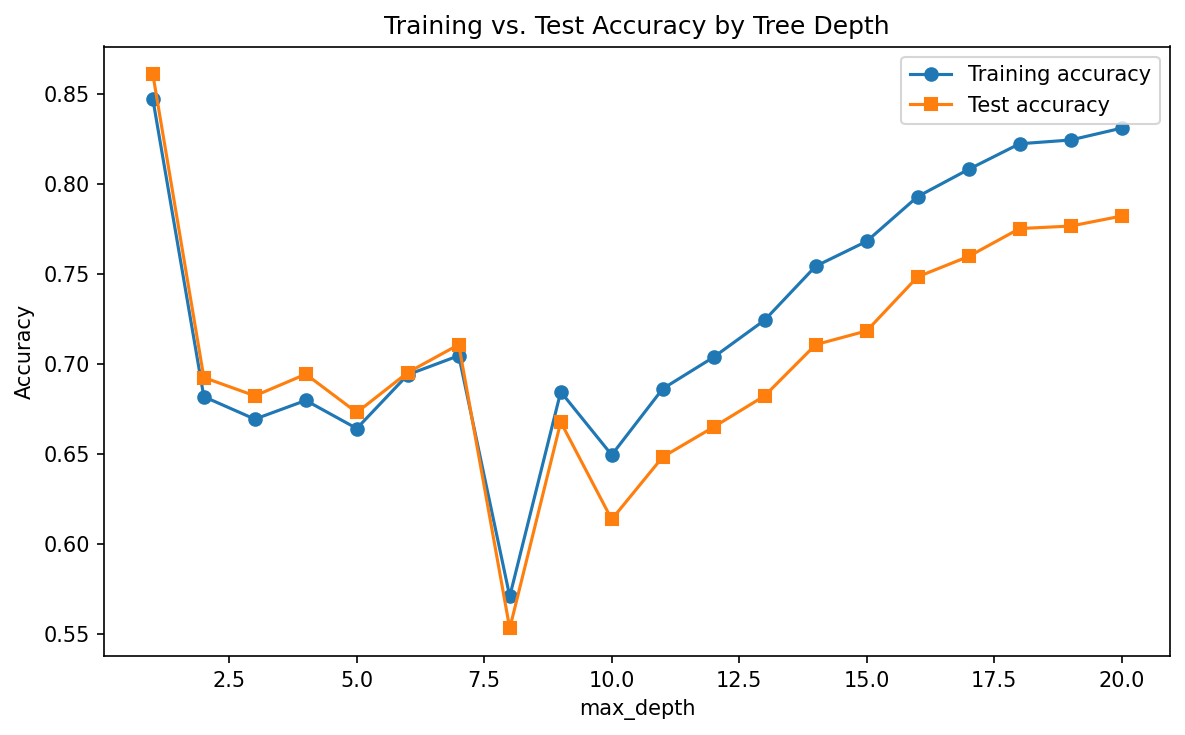

In [155]:
depths = range(1, 21)
train_acc = []
test_acc = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=272)
    dt.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(depths, train_acc, 'o-', label='Training accuracy')
plt.plot(depths, test_acc, 's-', label='Test accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Training vs. Test Accuracy by Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

Training accuracy climbs as the tree gets deeper, but test accuracy levels off or even drops. The gap between the two is a sign of **overfitting**.

**Note at depth 1–2**: The tree is still very simple, so it finds one or two broad splits that work well overall. Accuracy is decent, but it may still be mostly “Employed”-driven so we are likely not predicting any unemployed.

Let's check **recall** with tree depth

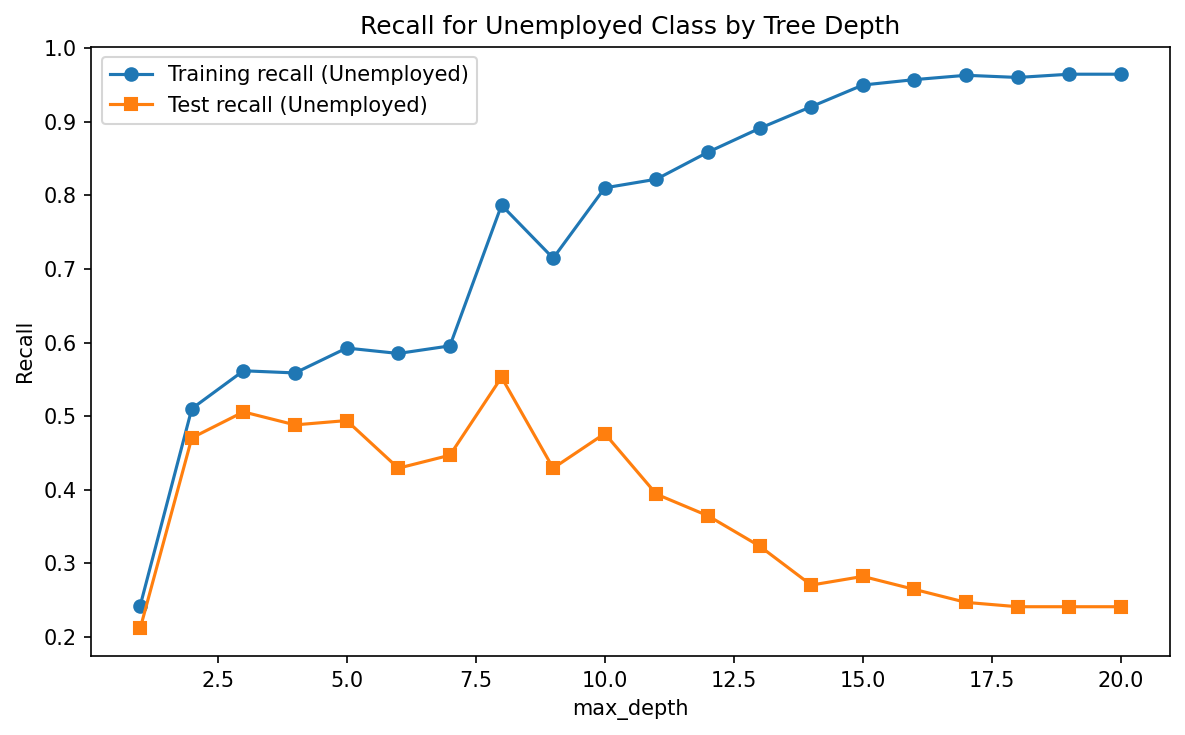

In [156]:
# Recall for the Unemployed class by tree depth
from sklearn.metrics import recall_score

train_recall = []
test_recall = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=272)
    dt.fit(X_train, y_train)
    train_recall.append(recall_score(y_train, dt.predict(X_train), pos_label=0))
    test_recall.append(recall_score(y_test, dt.predict(X_test), pos_label=0))

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(depths, train_recall, 'o-', label='Training recall (Unemployed)')
plt.plot(depths, test_recall, 's-', label='Test recall (Unemployed)')
plt.xlabel('max_depth')
plt.ylabel('Recall')
plt.title('Recall for Unemployed Class by Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

We see that training recall (blue) keeps rising toward 1.0 as depth increases. That means deeper trees can almost always “find rules” that capture nearly all unemployed cases in the training set.

Test recall (orange) peaks around depth ~4–6 (0.60) and then steadily falls as depth grows, down near 0.20 by depth ~18–20. 

This is a textbook sign of overfitting for the unemployed class: the tree is learning patterns that look predictive in the training sample but don’t hold up in new data.

## Recap: Gini Impurity

From Lecture 5, we learned that decision trees choose splits that **reduce** Gini impurity as much as possible, creating child nodes that are more class-pure than the parent.

The **Gini index** measures how mixed the classes are in a node (i.e. how impure the node is). For binary classification,

$$G(t) = 2p(1-p),$$

where $p$ is the proportion of samples in class 1 and $1-p$ is the proportion in class 0.

- $G = 0$: pure node (all one class)
- $G = 0.5$: maximally mixed (50/50)

The tree chooses the split that produces the largest **impurity decrease**:

$$\Delta\text{Gini} = G(t) - \left(\frac{n_L}{n}\,G(t_L) + \frac{n_R}{n}\,G(t_R)\right)$$

**NOTE**: for multiple classes (categorical outcomes) the Gini index is generalized to

$$G(t)=1-\sum_{k=1}^K p_k^2$$

This is for K classes with proportions p_1,\dots,p_K in node t, and the above equation reduces to 2p(1-p) when K=2.

## Recap: Stopping Rules (Pre-Pruning)

Last class we saw that trees stop splitting when:

1. The node is **pure** (Gini = 0).
2. No split produces enough **impurity decrease** (`min_impurity_decrease`).
3. The node has **too few samples** (`min_samples_split`, `min_samples_leaf`).
4. The tree reaches its **maximum depth** (`max_depth`).
5. No valid split exists (all feature values are identical).

These are all forms of **pre-pruning**: we decide *before* splitting whether to stop.

**Problem:** How do we choose `max_depth = 3` vs. `5` vs. `10`? Choosing too small a tree *underfits*; too large a tree *overfits*.

## Post-Pruning: Cost-Complexity Pruning

Instead of deciding *before* growing the tree how large it should be (pre-pruning), we can:

1. **Grow a full tree** (no restrictions).
2. **Prune it back** by removing branches that don't improve performance enough.

This is called **post-pruning** or **cost-complexity pruning**.

### The cost-complexity criterion

For a subtree $T$ with $|T|$ terminal nodes, the cost-complexity measure is:

$$R_\alpha(T) = R(T) + \alpha\,|T|,$$

where:
- $R(T)$ is the total impurity (misclassification rate or Gini) of all leaves,
- $|T|$ is the number of terminal nodes (leaves),
- $\alpha \ge 0$ is the **complexity parameter** (`ccp_alpha` in sklearn).

**Intuition:**
- $\alpha = 0$: no penalty for complexity → keep the full tree.
- Large $\alpha$: heavy penalty for each leaf → prune aggressively → smaller tree.
- We want to find the $\alpha$ that balances fit and simplicity.

**Note:**
- Finding the best complexity parameter $\alpha$ can be computationally expensive. To have a ballpark value for the maximum $\alpha$ to sample, we can use `complexity_pruning_path`. It takes a full tree and repeatedly looks at internal nodes to compute an "effective alpha" for each candidate subtree, finding the smallest effective alpha.

In [157]:
# Get the pruning path from the full tree
path = dt_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[path.ccp_alphas >= 0]
alpha_max = ccp_alphas.max()

# Subsample to 50 evenly spaced values — no need to know the range in advance
ccp_alphas_sub = np.linspace(0, alpha_max, 50)

print(f"alpha_max: {alpha_max:.6f}")
print(f"Searching over {len(ccp_alphas_sub)} alpha values")

alpha_max: 0.010874
Searching over 50 alpha values


Let's use 10-fold cross-validation between alpha = 0 and alpha_max found above to find the best `ccp_alpha`

In [158]:
cv_scores = []
for alpha in ccp_alphas_sub:
    dt = DecisionTreeClassifier(ccp_alpha=alpha, class_weight='balanced', random_state=272)
    scores = cross_val_score(dt, X_train, y_train, cv=10, scoring='balanced_accuracy')
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)

# Find the best alpha
best_idx = np.argmax(cv_scores)
best_alpha = ccp_alphas_sub[best_idx]
print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Best CV balanced accuracy: {cv_scores[best_idx]:.4f}")

Best ccp_alpha: 0.002219
Best CV balanced accuracy: 0.6157


Plot it!

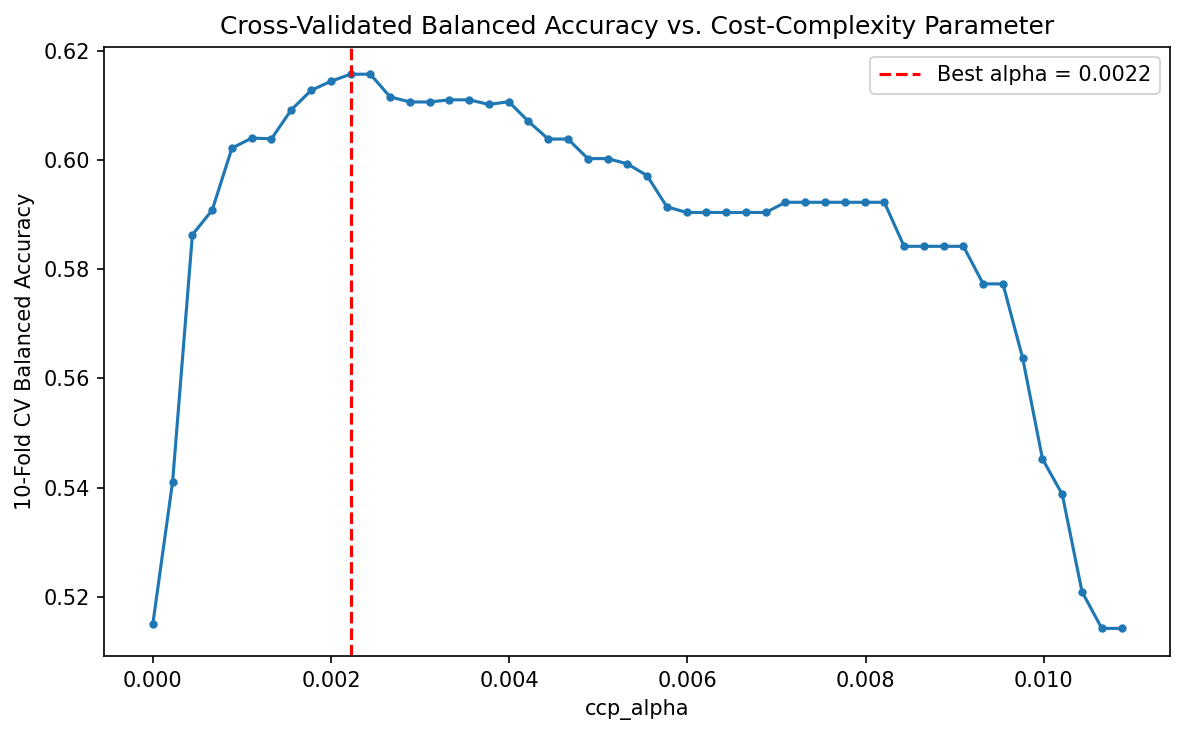

In [159]:
plt.figure(figsize=(8, 5), dpi=150)
plt.plot(ccp_alphas_sub, cv_scores, 'o-', markersize=3)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha = {best_alpha:.4f}')
plt.xlabel('ccp_alpha')
plt.ylabel('10-Fold CV Balanced Accuracy')
plt.title('Cross-Validated Balanced Accuracy vs. Cost-Complexity Parameter')
plt.legend()
plt.tight_layout()
plt.show()

Now we fit the tree again with the best `ccp_alpha` to prune the tree

In [160]:
# Fit the pruned tree with the best alpha
dt_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, class_weight='balanced', random_state=272)
dt_pruned.fit(X_train, y_train)

print(f"Pruned tree depth: {dt_pruned.get_depth()}")
print(f"Pruned tree leaves: {dt_pruned.get_n_leaves()}")
print(f"Training accuracy: {accuracy_score(y_train, dt_pruned.predict(X_train)):.3f}")
print(f"Test accuracy:     {accuracy_score(y_test, dt_pruned.predict(X_test)):.3f}")

Pruned tree depth: 6
Pruned tree leaves: 7
Training accuracy: 0.622
Test accuracy:     0.631


And plot the pruned tree

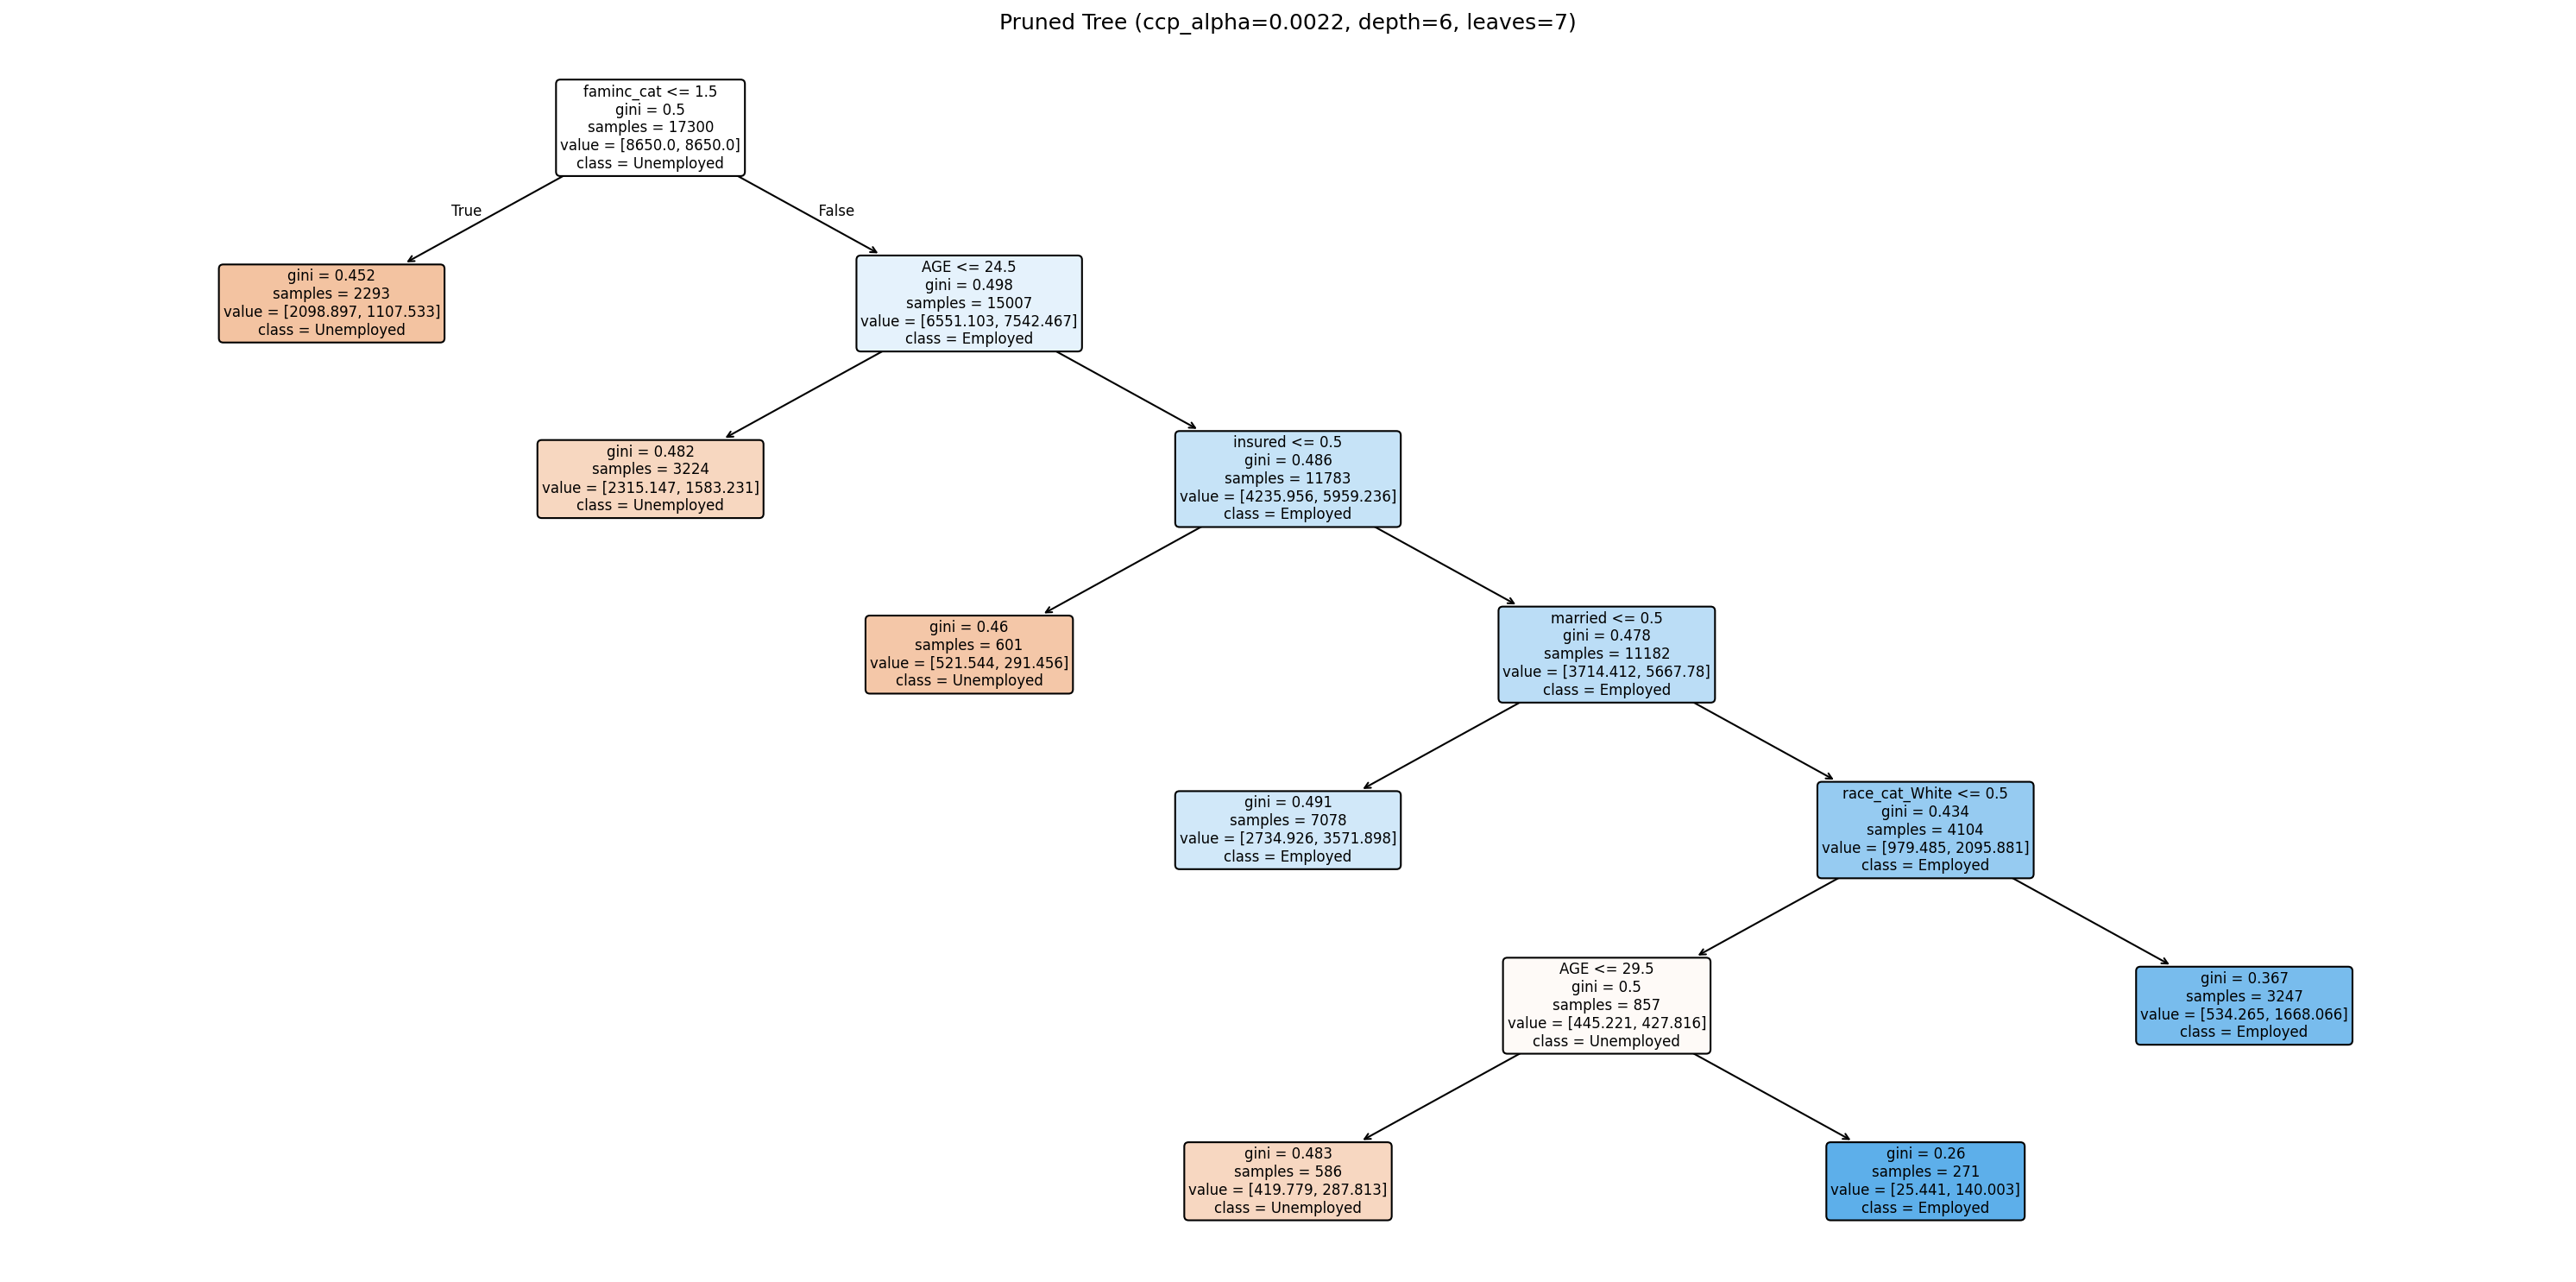

In [161]:

plt.figure(figsize=(20, 10), dpi=150)
plot_tree(dt_pruned,
          feature_names=feature_cols,
          class_names=['Unemployed', 'Employed'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title(f"Pruned Tree (ccp_alpha={best_alpha:.4f}, depth={dt_pruned.get_depth()}, leaves={dt_pruned.get_n_leaves()})")
plt.tight_layout()
plt.show()

First split is faminc_cat <= 1.5 -- this variable is doing the biggest separation.
- If faminc_cat <= 1.5 (True, left): the tree immediately predicts Unemployed (orange leaf).
Interpretation: being in the lowest family-income category/categories is a strong signal for unemployment in this model.
- If faminc_cat > 1.5 (False, right): you move into the “mostly employed” side, and the tree needs more info (age, insurance, marital status, race indicator) to decide.

Next split: AGE <= 24.5
- If AGE <= 24.5: it predicts Unemployed.
Interpretation: among those not in the lowest income category, very young age is associated with unemployment (or at least being classified that way).
- If AGE > 24.5: go deeper.

Next: insured <= 0.5 (binary indicator)
- If not insured (insured = 0): predict Unemployed.
Strong intuitive rule: lack of insurance is associated with unemployment.
- If insured (insured = 1): go deeper.

Then married, race, age <29.5

## The Variance Problem with Single Trees

A single decision tree is **high variance**: if you change the training data slightly, the tree structure can change dramatically.

- Different random splits of the data → different trees → different predictions.
- Even with pruning, a single tree can be unstable.

**Idea:** What if we built *many* trees and averaged their predictions? This is the key insight behind **bagging** and **random forests**.

### What is Bootstrapping?

Before we can understand Bagging, we need to understand **bootstrapping** — a simple but powerful resampling idea.

Suppose you have a training dataset of $n$ observations. A **bootstrap sample** is created by:

1. Drawing $n$ observations **with replacement** from your dataset.
2. Because sampling is with replacement, some observations will appear **more than once**, and others **not at all**.
3. On average, about **63.2%** of the original observations appear in each bootstrap sample (the rest are called the *out-of-bag* observations).

#### Example

Suppose your dataset is: `[A, B, C, D, E]`

One bootstrap sample might be: `[A, A, C, D, D]` — A and D appear twice, B and E are left out.

Another bootstrap sample might be: `[B, C, C, C, E]` — C appears three times, A and D are left out.

Each bootstrap sample gives us a slightly **different dataset**, which we can use to fit a slightly **different model**.

#### Why do we care?

Bootstrapping lets us simulate the effect of having collected many different training datasets, using just the one we have. When we average predictions across models trained on different bootstrap samples, we reduce the variance of our predictions without increasing bias.

## Bagging (Bootstrap Aggregating)

Proposed by [Leo Breiman (1996)](https://link.springer.com/article/10.1007/BF00058655).

### Algorithm

1. Draw $B$ **bootstrap samples** from the training data. Each bootstrap sample is the same size as the original data but drawn **with replacement** (so some observations appear multiple times, others not at all).

2. Fit a **full decision tree** (no pruning) to each bootstrap sample.

3. To predict a new observation:
   - Each tree makes a prediction (a class label or probability).
   - The final prediction is the **majority vote** (for classification) or the **average probability** across all $B$ trees.

### Why does this work?

- Each individual tree overfits (high variance, low bias).
- But the **average** of many overfitting trees has **lower variance** while keeping the low bias.
- This is the statistical principle that $\text{Var}(\bar{X}) = \frac{\sigma^2}{n}$ — averaging reduces variance.

In [162]:
# Bagging with 100 trees
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=272),
    n_estimators=100,
    max_samples=1.0,       # each bootstrap sample is the same size as training data
    bootstrap=True,        # sample with replacement
    random_state=272
)
bag_clf.fit(X_train, y_train)

print(f"Bagging training accuracy: {accuracy_score(y_train, bag_clf.predict(X_train)):.3f}")
print(f"Bagging test accuracy:     {accuracy_score(y_test, bag_clf.predict(X_test)):.3f}")

Bagging training accuracy: 0.885
Bagging test accuracy:     0.847


In [163]:
print("Bagging Classification Report:")
print()
print(classification_report(y_test, bag_clf.predict(X_test),
                            target_names=['Unemployed', 'Employed'], digits=3))

Bagging Classification Report:

              precision    recall  f1-score   support

  Unemployed      0.048     0.153     0.073       170
    Employed      0.962     0.875     0.916      4156

    accuracy                          0.847      4326
   macro avg      0.505     0.514     0.494      4326
weighted avg      0.926     0.847     0.883      4326



Yay! Unemployed precision and recall are no longer 0.

## From Bagging to Random Forests

Bagging helps, but there is a subtle problem: if one feature is very strong, **every bootstrap tree will split on that feature first**. The trees end up being very similar to each other (correlated), which limits how much variance reduction we get.

### The Random Forest Fix

**Random forests** ([Breiman, 2001](https://link.springer.com/article/10.1023/A:1010933404324)) add one extra step to bagging:

> At each split, only consider a **random subset** of $m$ features (out of the total $p$ features).

This **decorrelates** the trees: different trees will use different features for their early splits, making the ensemble more diverse.

### Key parameters

- `n_estimators`: number of trees $B$ from bootstrapped samples (more is generally better, but with diminishing returns). So `n_estimators=100` means 100 bootstrap samples, each producing one tree, whose predictions are then averaged.
- `max_features`: number of features $m$ to consider at each split.
  - Common default for classification: $m = \sqrt{p}$, which sklearn sets with `max_features='sqrt'`.
  - If $m = p$, random forest is the same as bagging (all features considered at every split).

In [170]:
# Random Forest with 25 trees (updated based on below)
rf_clf = RandomForestClassifier(
    n_estimators=25,
    max_features='sqrt',
    class_weight='balanced',
    random_state=272
)
rf_clf.fit(X_train, y_train)

print(f"Random Forest training accuracy: {accuracy_score(y_train, rf_clf.predict(X_train)):.3f}")
print(f"Random Forest test accuracy:     {accuracy_score(y_test, rf_clf.predict(X_test)):.3f}")

Random Forest training accuracy: 0.891
Random Forest test accuracy:     0.858


In [171]:
print("Random Forest Classification Report:")
print()
print(classification_report(y_test, rf_clf.predict(X_test),
                            target_names=['Unemployed', 'Employed'], digits=3))

Random Forest Classification Report:

              precision    recall  f1-score   support

  Unemployed      0.049     0.141     0.073       170
    Employed      0.962     0.888     0.923      4156

    accuracy                          0.858      4326
   macro avg      0.505     0.514     0.498      4326
weighted avg      0.926     0.858     0.890      4326



## Effect of Number of Trees

How does test accuracy change as we increase `n_estimators`?

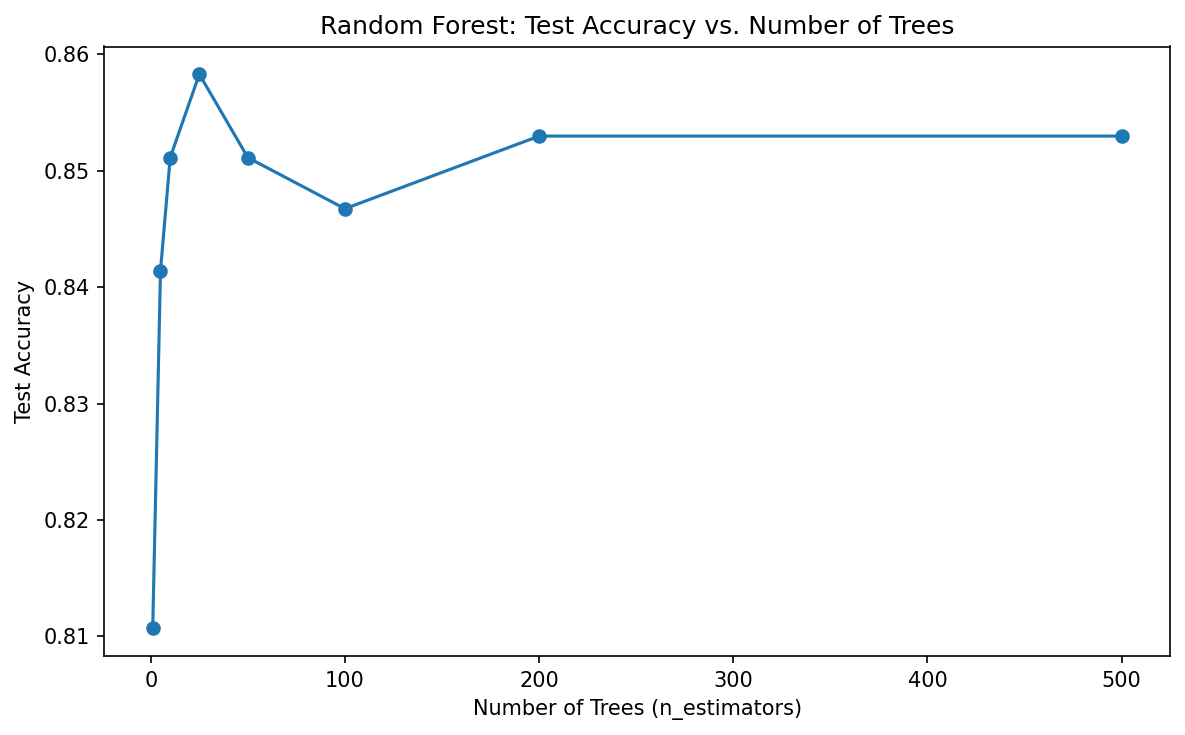

In [172]:
n_trees_list = [1, 5, 10, 25, 50, 100, 200, 500]
rf_test_acc = []

for n_trees in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n_trees, max_features='sqrt',
                                class_weight='balanced', random_state=272)
    rf.fit(X_train, y_train)
    rf_test_acc.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(n_trees_list, rf_test_acc, 'o-')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Test Accuracy')
plt.title('Random Forest: Test Accuracy vs. Number of Trees')
plt.tight_layout()
plt.show()

**Observation:** Performance improves quickly as we add more trees, then levels off. Unlike single trees, random forests do **not** overfit as the number of trees increases — adding more trees only helps (or is neutral).

### Common random forest "hyperparameters" that can be tuned

`n_estimators` — number of trees. More is generally better but with diminishing returns; usually 100–500 is enough.
`max_features` — features considered at each split. Default 'sqrt' works well for classification; reducing it decorrelates trees more but each tree is weaker. Other options are log$_2$(p) `max_features=log2`, or a fraction of features (e.g. half `max_features=0.5`).
`max_depth` — limits tree depth. By default trees are fully grown (None); restricting it can reduce overfitting.
`min_samples_leaf` — minimum observations in a leaf. Increasing it smooths the model and reduces overfitting.

## Variable Importance (Mean Decrease in Gini / Gain)

One of the most useful features of tree-based models is **variable importance**.

### How is importance computed?

For each feature, we sum up the **total decrease in Gini impurity** (i.e., the gain) it produces across all splits in all trees:

$$\text{Importance}(x_j) = \sum_{\text{trees}} \sum_{\substack{\text{nodes where}\\\text{feature } j \text{ is used}}} n_t \cdot \Delta G(t),$$

where $n_t$ is the number of samples reaching node $t$ and $\Delta G(t)$ is the Gini decrease at that node.

The values are then **normalized** so they sum to 1.

- In sklearn, this is stored in `feature_importances_` and is sometimes called **"Gini importance"** or **"mean decrease in impurity"**.
- A high importance means the feature was used frequently for splits that produced large decreases in impurity.

In [177]:
# Variable importance from the random forest
importances = rf_clf.feature_importances_
feature_names = rf_clf.feature_names_in_

importance_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
                 .sort_values('Importance', ascending=False))

print(importance_df.to_string(index=False))

       Feature  Importance
           AGE    0.290574
          YEAR    0.252358
    faminc_cat    0.098394
        female    0.049773
       married    0.046083
race_cat_White    0.043795
      educ_cat    0.041299
    us_citizen    0.037384
  metro_binary    0.028952
race_cat_Black    0.028368
       insured    0.026902
        NCHILD    0.025177
race_cat_Other    0.015820
  has_children    0.015121


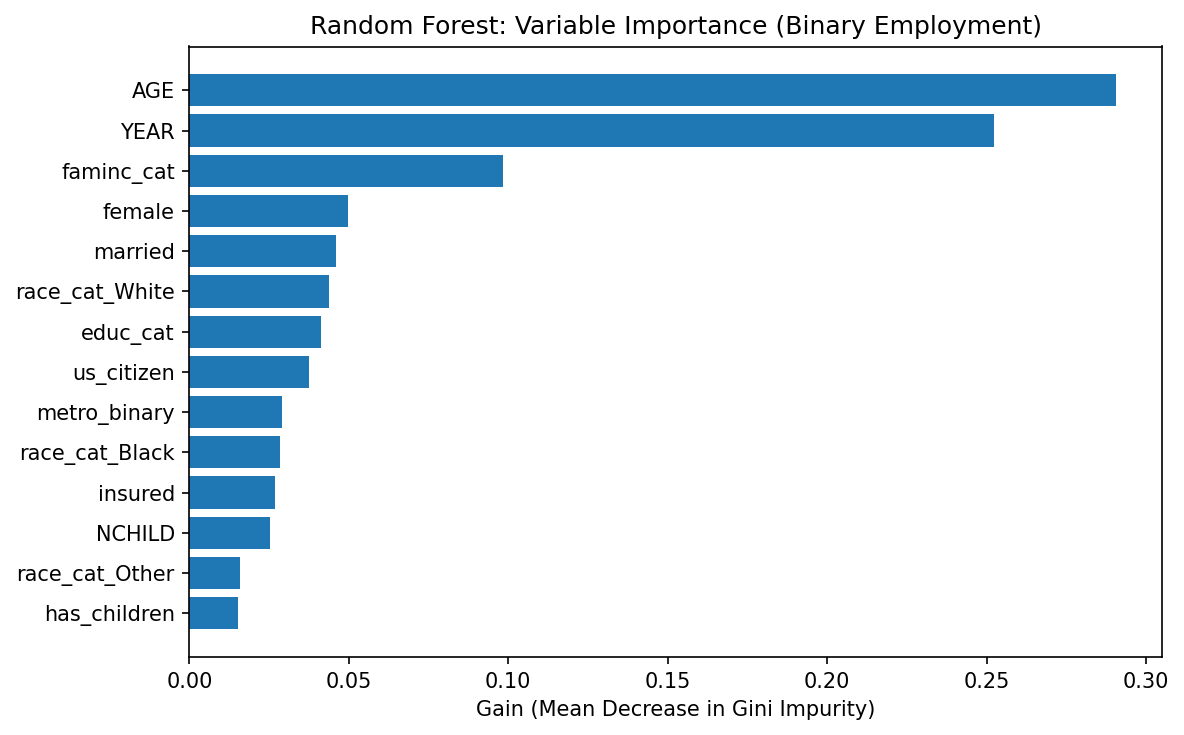

In [178]:
# Plot variable importance
plt.figure(figsize=(8, 5), dpi=150)
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Gain (Mean Decrease in Gini Impurity)')
plt.title('Random Forest: Variable Importance (Binary Employment)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Comparing All Models (Binary Classification)

Let's compare the single tree, the pruned tree, the bagged tree, and the random forest on the binary employment outcome.

In [179]:
models = {
    'Restricted Tree (max_depth=15)': dt_restricted,
    'Pruned Tree (ccp_alpha)': dt_pruned,
    'Bagging (100 trees)': bag_clf,
    'Random Forest (25 trees)': rf_clf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    p1 = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, p1)
    print(f"{name:35s}  Accuracy: {acc:.3f}  AUC: {auc:.3f}")

Restricted Tree (max_depth=15)       Accuracy: 0.634  AUC: 0.542
Pruned Tree (ccp_alpha)              Accuracy: 0.631  AUC: 0.614
Bagging (100 trees)                  Accuracy: 0.847  AUC: 0.555
Random Forest (25 trees)             Accuracy: 0.858  AUC: 0.546


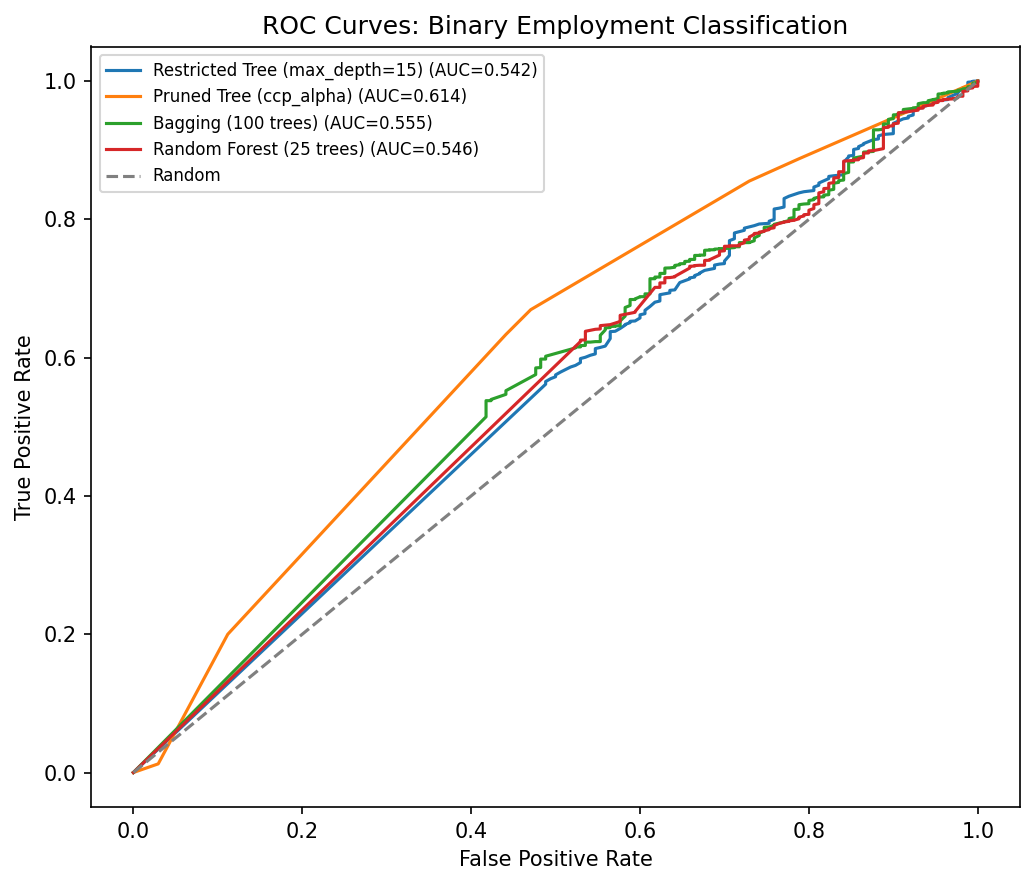

In [180]:
# ROC curves for all models
plt.figure(figsize=(7, 6), dpi=150)

for name, model in models.items():
    p1 = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p1)
    auc = roc_auc_score(y_test, p1)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Binary Employment Classification')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary

| Method | Key Idea | Strengths | Weaknesses |
|--------|----------|-----------|------------|
| **Single tree** | One tree with stopping rules | Simple, interpretable | High variance, can overfit |
| **Pruned tree** | Grow full tree, cut back with $\alpha$ | Better than stopping rules | Still a single tree (variance) |
| **Bagging** | Average $B$ bootstrap trees | Lower variance | Trees can be correlated |
| **Random forest** | Bagging + random feature subsets | Lower variance, decorrelated trees | Less interpretable than single tree |

### Key Takeaways

1. **Pruning** (pre or post) helps single trees avoid overfitting.
2. **Bagging** reduces variance by averaging many trees.
3. **Random forests** improve on bagging by decorrelating the trees.
4. **Variable importance** (mean decrease in Gini) tells us which features are most useful for prediction — and is more stable when computed from a random forest than a single tree.
5. Random forests handle both **binary** and **multi-class** classification naturally.

## Extension: Predicting Wages (Continuous Outcome)

So far we have predicted a binary outcome (employed vs. unemployed). Tree-based methods extend naturally to **continuous outcomes** — the only change is how we measure the quality of a split.

### How Regression Trees Work

In a **classification tree**, splits are chosen to reduce **Gini impurity** — a measure of how mixed the classes are in each node.

In a **regression tree**, splits are chosen to reduce **mean squared error (MSE)**. At each node, the tree asks: *which feature and threshold minimises the weighted MSE across the two child nodes?*

For a node containing observations $\{y_1, y_2, \ldots, y_n\}$, the MSE is:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2$$

where $\bar{y}$ is the mean of the node. The tree searches over all features and all possible split points to find the split that minimises the **total weighted MSE** of the two child nodes:

$$\text{MSE}_{\text{split}} = \frac{n_L}{n} \cdot \text{MSE}_L + \frac{n_R}{n} \cdot \text{MSE}_R$$

**Prediction**: once the tree is grown, the predicted value for a new observation is the **mean of the training outcomes** in the leaf it falls into.

Everything else — stopping rules, pruning, bagging, random forests — works exactly the same as for classification.

### Should we Log-Transform?

Like we saw in the movies revenue and budget data, wage income is highly right-skewed (a few very high earners inflate the variance). Predicting raw wages leads to large MSE driven by outliers. Taking $\log(\text{INCWAGE})$ compresses the distribution, making it easier to predict and more in line with how wages are analysed in labour economics.

We:
- Restrict to employed workers with positive wages (`INCWAGE > 0`)
- Predict $\log(\text{INCWAGE})$ — RMSE and R² are on the log-dollar scale

Let's first look at the distribution of wages before and after the log transformation.

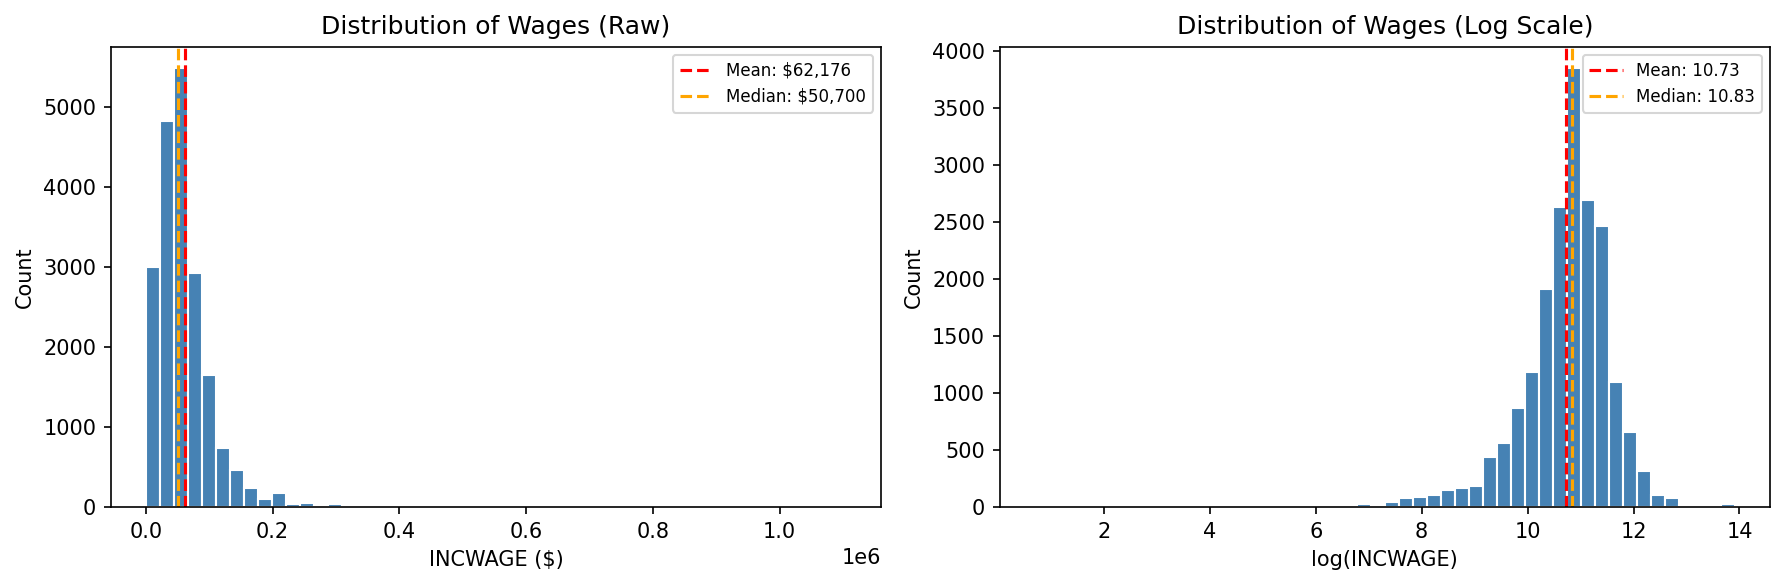

In [181]:
cps_pos = cps_encoded[(cps_encoded['employed'] == 1) & (cps_encoded['INCWAGE'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

# Raw INCWAGE
axes[0].hist(cps_pos['INCWAGE'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('INCWAGE ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Wages (Raw)')
axes[0].axvline(cps_pos['INCWAGE'].mean(), color='red', linestyle='--', label=f'Mean: ${cps_pos["INCWAGE"].mean():,.0f}')
axes[0].axvline(cps_pos['INCWAGE'].median(), color='orange', linestyle='--', label=f'Median: ${cps_pos["INCWAGE"].median():,.0f}')
axes[0].legend(fontsize=8)

# Log INCWAGE
axes[1].hist(np.log(cps_pos['INCWAGE']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log(INCWAGE)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Wages (Log Scale)')
axes[1].axvline(np.log(cps_pos['INCWAGE']).mean(), color='red', linestyle='--', label=f'Mean: {np.log(cps_pos["INCWAGE"]).mean():.2f}')
axes[1].axvline(np.log(cps_pos['INCWAGE']).median(), color='orange', linestyle='--', label=f'Median: {np.log(cps_pos["INCWAGE"]).median():.2f}')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Let's fit the decision tree, bagging, and random forest. We also introduce two other variables that were not in the previous example `OCC` and `IND`, which are codes for occupation and industry categories.

Also note we use `DecisionTreeRegressor`, `BaggingRegressor`, and `RandomForestRegressor` rather than their classification counterparts.

Finally, for metrics in regression trees we use `mean_squared_error` and `r2_score` from `sklearn.metrics` computed on the test values (comparing the test observations to the test predictions).

It computes the average of squared prediction errors:
$$\text{MSE}=\frac{1}{n}\sum_{i=1}^n (y_i-\hat y_i)^2$$
Units are “y-units squared” (I prefer reporting RMSE $=\sqrt{\text{MSE}}$ to get back to original units).

And the coefficient of determination:
$$R^2 = 1 - \frac{\sum_{i=1}^n (y_i-\hat y_i)^2}{\sum_{i=1}^n (y_i-\bar y)^2}
= 1 - \frac{\text{SSE}}{\text{SST}}$$


In [182]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Filter to employed workers with positive wages
cps_empl = cps_encoded[(cps_encoded['employed'] == 1) & (cps_encoded['INCWAGE'] > 0)].copy()

# Log-transform wages
cps_empl['log_wage'] = np.log(cps_empl['INCWAGE'])

# Predictor variables — include OCC and IND as numeric codes (trees handle these well), note we do not use employment status since wage would be 0
reg_feature_cols = ['AGE', 'female', 'married', 'educ_cat', 'faminc_cat',
                    'metro_binary', 'us_citizen', 'has_children', 'insured',
                    'OCC', 'IND', 'FIRMSIZE', 'NCHILD', 'YEAR',
                    'race_cat_Black', 'race_cat_Other', 'race_cat_White']

X_reg = cps_empl[reg_feature_cols]
y_reg = cps_empl['log_wage']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=272
)

print(f'Training set: {X_train_r.shape[0]:,} observations')
print(f'Test set:     {X_test_r.shape[0]:,} observations')
print(f'Mean log wage (train):   {y_train_r.mean():.3f}')
print(f'Mean wage (train):       ${np.exp(y_train_r.mean()):,.0f}')

Training set: 15,872 observations
Test set:     3,968 observations
Mean log wage (train):   10.730
Mean wage (train):       $45,712


### Regression Tree

In [183]:
dt_reg = DecisionTreeRegressor(max_depth=3, random_state=272)
dt_reg.fit(X_train_r, y_train_r)

rmse_baseline = np.sqrt(mean_squared_error(y_test_r, np.full(len(y_test_r), y_train_r.mean())))
rmse_dt = np.sqrt(mean_squared_error(y_test_r, dt_reg.predict(X_test_r)))
r2_dt   = r2_score(y_test_r, dt_reg.predict(X_test_r))

print(f'Decision Tree RMSE: {rmse_dt:.3f}  |  R² = {r2_dt:.3f}')
print(f'(RMSE is in log-dollar units)')

Decision Tree RMSE: 0.776  |  R² = 0.180
(RMSE is in log-dollar units)


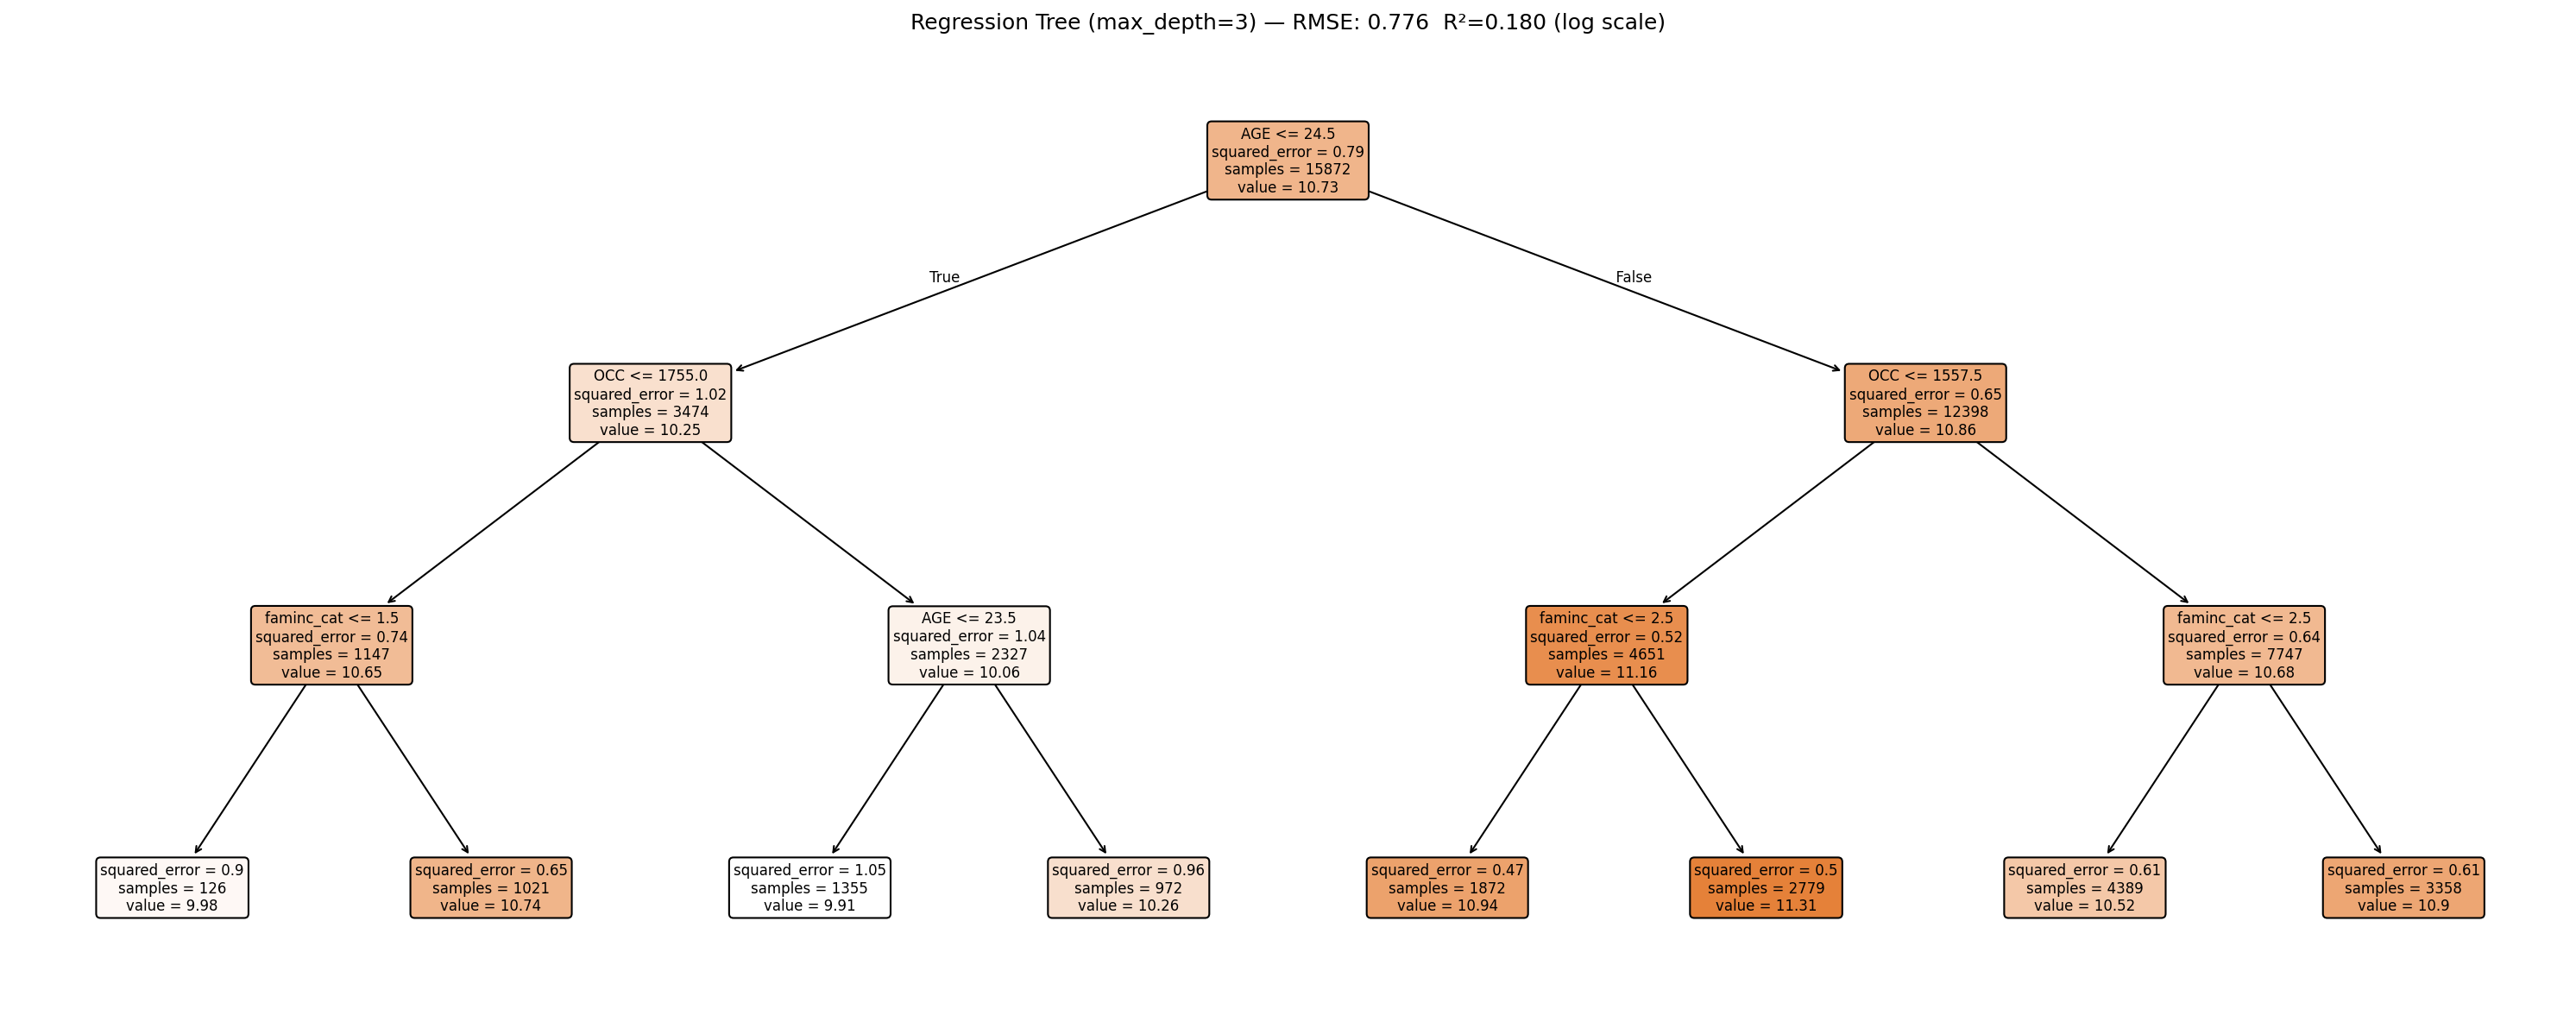

In [184]:
plt.figure(figsize=(20, 8), dpi=150)
plot_tree(dt_reg,
          feature_names=reg_feature_cols,
          filled=True,
          rounded=True,
          fontsize=8,
          precision=2)
plt.title(f'Regression Tree (max_depth=3) — RMSE: {rmse_dt:.3f}  R²={r2_dt:.3f} (log scale)')
plt.tight_layout()
plt.show()

### Bagging

Let's also try adding `min_samples_leaf = 5`. In bagging and random forests, increasing it helps mainly by regularizing each tree so the ensemble isn’t built from extremely wiggly, noise-fitting trees.

In [185]:
bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(min_samples_leaf=5, random_state=272),
    n_estimators=100,
    random_state=272
)
bag_reg.fit(X_train_r, y_train_r)

rmse_bag = np.sqrt(mean_squared_error(y_test_r, bag_reg.predict(X_test_r)))
r2_bag   = r2_score(y_test_r, bag_reg.predict(X_test_r))
print(f'Bagging RMSE: {rmse_bag:.3f}  |  R² = {r2_bag:.3f}')

Bagging RMSE: 0.730  |  R² = 0.274


### Random Forest

In [186]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_features=0.5,
    min_samples_leaf=5,
    random_state=272
)
rf_reg.fit(X_train_r, y_train_r)

rmse_rf = np.sqrt(mean_squared_error(y_test_r, rf_reg.predict(X_test_r)))
r2_rf   = r2_score(y_test_r, rf_reg.predict(X_test_r))
print(f'Random Forest RMSE: {rmse_rf:.3f}  |  R² = {r2_rf:.3f}')

Random Forest RMSE: 0.724  |  R² = 0.287


### Model Comparison

In [187]:
results = {
    'Baseline (mean log wage)':  (rmse_baseline, None),
    'Decision Tree (depth 3)':   (rmse_dt,       r2_dt),
    'Bagging (100 trees)':       (rmse_bag,      r2_bag),
    'Random Forest (200 trees)': (rmse_rf,       r2_rf),
}

print(f"{'Model':<30} {'RMSE (log $)':>14} {'R²':>8}")
print('-' * 54)
for name, (rmse, r2) in results.items():
    r2_str = f'{r2:.3f}' if r2 is not None else '—'
    print(f'{name:<30} {rmse:>14.3f} {r2_str:>8}')

Model                            RMSE (log $)       R²
------------------------------------------------------
Baseline (mean log wage)                0.857        —
Decision Tree (depth 3)                 0.776    0.180
Bagging (100 trees)                     0.730    0.274
Random Forest (200 trees)               0.724    0.287


### Variable Importance for Continous Outcome (Random Forest)

Interpreting Variable Importance in Regression Tree Methods:

The **gain** of a feature measures how much it reduces the prediction error (MSE) across all splits in the forest.

For each split in each tree that uses feature $j$:

$$\text{Gain}_j = \text{MSE}_{\text{parent}} - \left(\frac{n_L}{n} \cdot \text{MSE}_L + \frac{n_R}{n} \cdot \text{MSE}_R\right)$$

This is the reduction in MSE achieved by the split. The importance of feature $j$ is the **average gain** across all splits on $j$, weighted by the number of observations in the node, averaged over all trees in the forest.

Features are then **normalised** so that all importances sum to 1, making them easy to compare.

A high gain means the feature consistently produces splits that explain a large share of the variance in log wages. 

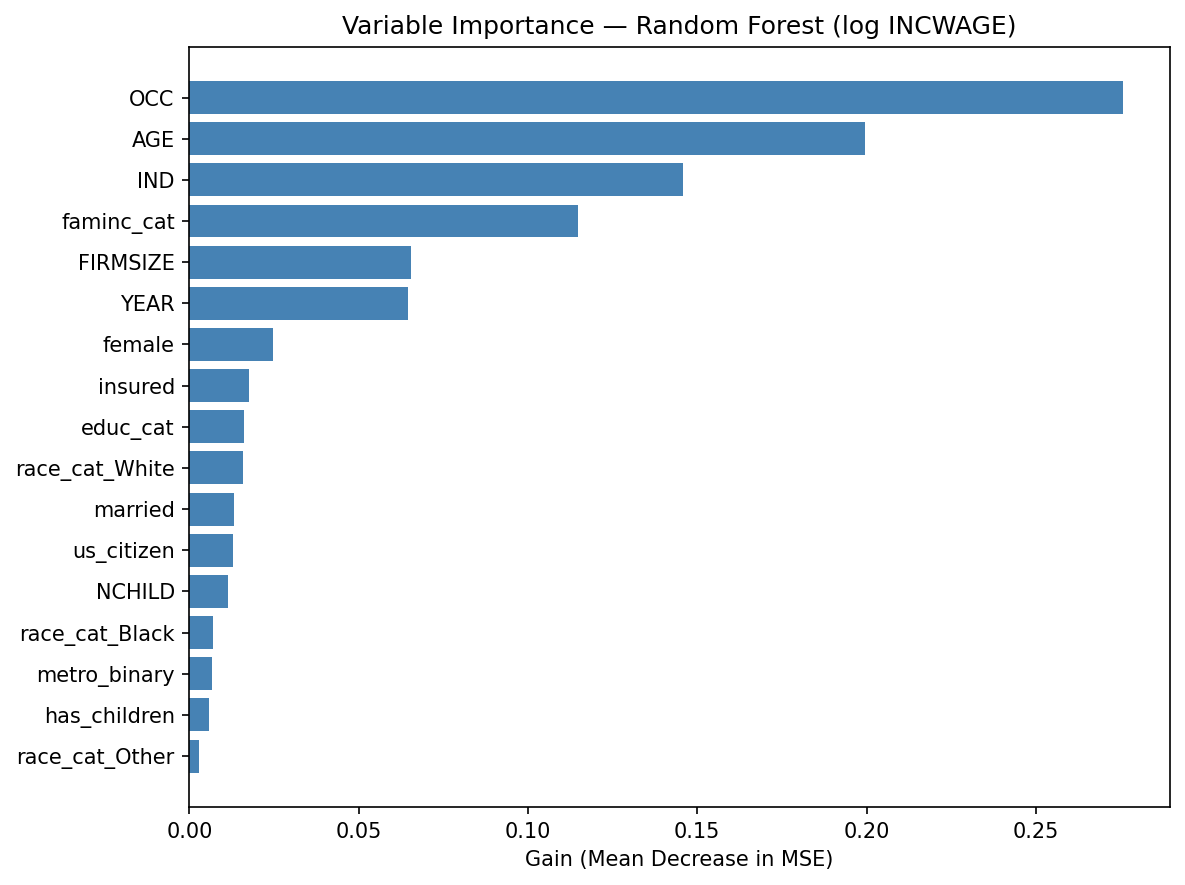

In [142]:
imp_df_reg = pd.DataFrame({
    'Feature': reg_feature_cols,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6), dpi=150)
plt.barh(imp_df_reg['Feature'], imp_df_reg['Importance'], color='steelblue')
plt.xlabel('Gain (Mean Decrease in MSE)')
plt.title('Variable Importance — Random Forest (log INCWAGE)')
plt.tight_layout()
plt.show()

We see variables like `OCC` (occupation) and `IND` (industry type) tend to rank highly because they directly reflect the type and scale of employment, which strongly predicts earnings.

### Observed vs. Predicted Wages (Back-Transformed)

Similar to what we did for linear regression, to interpret model performance on the original dollar scale, we back-transform using $\exp(\hat{y})$ and plot predicted vs. observed wages.

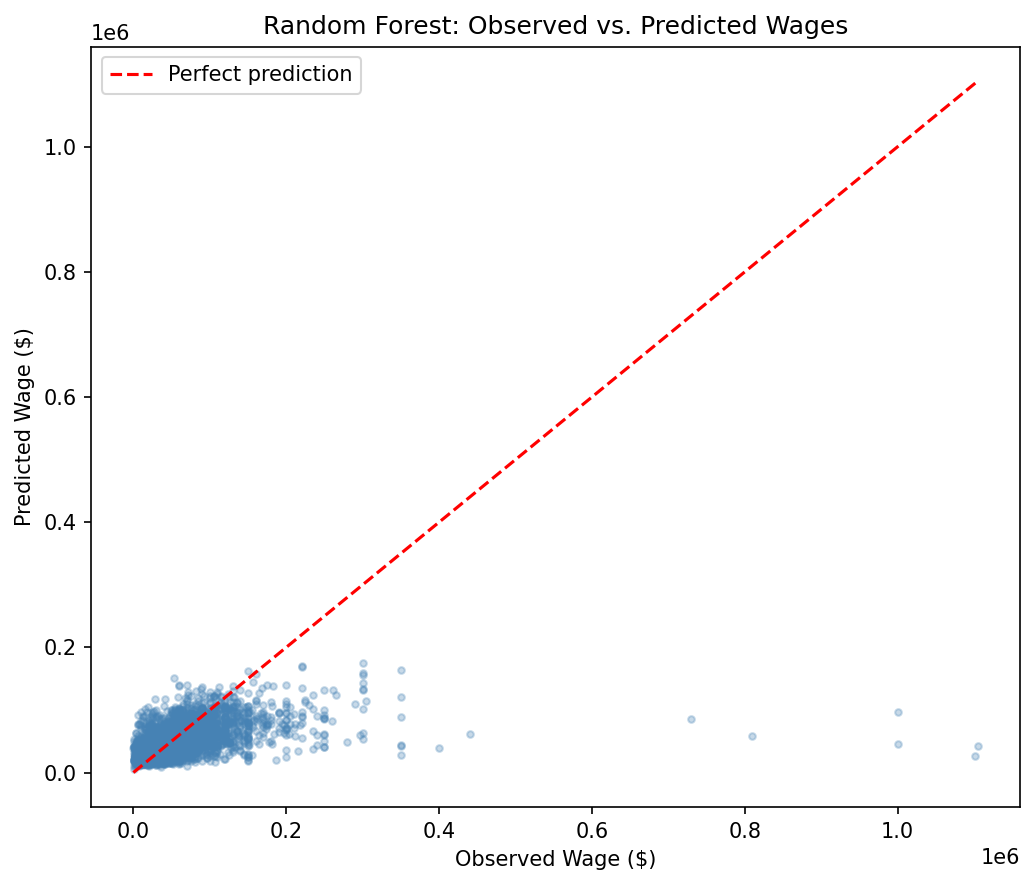

RMSE on original scale: $52,004


In [143]:
y_pred_rf = np.exp(rf_reg.predict(X_test_r))
y_obs     = np.exp(y_test_r)

plt.figure(figsize=(7, 6), dpi=150)
plt.scatter(y_obs, y_pred_rf, alpha=0.3, s=10, color='steelblue')

# 45-degree perfect prediction line
lim = max(y_obs.max(), y_pred_rf.max())
plt.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Observed Wage ($)')
plt.ylabel('Predicted Wage ($)')
plt.title('Random Forest: Observed vs. Predicted Wages')
plt.legend()
plt.tight_layout()
plt.show()

# Back-transformed RMSE (in dollars)
rmse_dollars = np.sqrt(np.mean((y_obs - y_pred_rf) ** 2))
print(f'RMSE on original scale: ${rmse_dollars:,.0f}')

Interpretation: We see significant underprediction of high wages, which is affecting our test metrics (lower R2 and higher RMSE).